# Prerequisites

In [1]:
!pip install torch torchvision matplotlib numpy

# Step 1: Imports and Configuration

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import copy

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
print(f"Running on device: {DEVICE}")

Running on device: cuda


# Step 2: The Probing Tools (Mathematical Methodology)

In [3]:
def compute_hessian_spectral_norm(model, criterion, data_loader, device, max_iter=10):
    """
    Methodology Section 4.2: Spectral Density Estimation
    Computes the top eigenvalue (lambda_max) of the Hessian using Power Iteration
    and Hessian-Vector Products (Pearlmutter's Trick).
    """
    model.eval()

    # 1. Initialize random vector v (same shape as parameters)
    v = [torch.randn_like(p) for p in model.parameters()]
    v = [vi / torch.norm(vi) for vi in v] # Normalize init

    # We only need a single batch to estimate local curvature
    data, target = next(iter(data_loader))
    data, target = data.to(device), target.to(device)

    eigenvalue = 0.0

    for i in range(max_iter):
        model.zero_grad()

        # A. Standard Forward/Backward to get Gradients
        output = model(data)
        loss = criterion(output, target)
        # create_graph=True is essential for the second derivative
        grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)

        # B. Compute HVP (Hessian-Vector Product)
        # Dot product of gradient and v
        grad_v_dot = sum([torch.sum(g * vi) for g, vi in zip(grads, v)])

        # Gradient of that scalar = Hv
        hvp = torch.autograd.grad(grad_v_dot, model.parameters(), retain_graph=True)

        # C. Power Iteration Update
        # The norm of Hv approximates the eigenvalue
        hvp_norm_sq = sum([torch.sum(h**2) for h in hvp])
        hvp_norm = torch.sqrt(hvp_norm_sq)

        # Normalize v for next iteration
        v = [h / (hvp_norm + 1e-6) for h in hvp]

        eigenvalue = hvp_norm.item()

    return eigenvalue

# Step 3: The Visualization Tools (Geometry)

In [4]:
def get_random_directions(model):
    """
    Methodology Section 4.3: Filter Normalization
    Generates random directions normalized by the weights of the filters.
    """
    x_direction = []
    y_direction = []

    for param in model.parameters():
        dx = torch.randn_like(param)
        dy = torch.randn_like(param)

        # Filter Normalization for Convolutions (dim 4) and FC layers (dim 2)
        if param.dim() >= 2:
            # Flatten to (Output_Filters, Input_Pixels)
            w_view = param.view(param.size(0), -1)
            dx_view = dx.view(dx.size(0), -1)
            dy_view = dy.view(dy.size(0), -1)

            # Compute norms
            w_norm = w_view.norm(dim=1, keepdim=True)
            dx_norm = dx_view.norm(dim=1, keepdim=True)
            dy_norm = dy_view.norm(dim=1, keepdim=True)

            # Scale random noise by weight norms
            dx_view.mul_(w_norm / (dx_norm + 1e-10))
            dy_view.mul_(w_norm / (dy_norm + 1e-10))

            dx = dx_view.view_as(param)
            dy = dy_view.view_as(param)

        x_direction.append(dx)
        y_direction.append(dy)

    return x_direction, y_direction

def compute_loss_surface(model, data_loader, criterion, device, resolution=21, range_val=1.0):
    """
    Scans the landscape grid.
    WARNING: Computationally expensive.
    Using a small subset of data_loader is recommended for speed.
    """
    w_0 = [p.data.clone() for p in model.parameters()]
    dir_x, dir_y = get_random_directions(model)

    alphas = np.linspace(-range_val, range_val, resolution)
    betas = np.linspace(-range_val, range_val, resolution)
    loss_surface = np.zeros((resolution, resolution))

    # Use a fixed subset of data for probing (e.g., 5 batches) to save time
    subset_data = []
    for i, (d, t) in enumerate(data_loader):
        if i >= 5: break
        subset_data.append((d.to(device), t.to(device)))

    print(f"Scanning Landscape ({resolution}x{resolution})...")

    with torch.no_grad():
        for i, alpha in enumerate(alphas):
            for j, beta in enumerate(betas):

                # Perturb Weights
                for k, param in enumerate(model.parameters()):
                    param.data = w_0[k] + \
                                 alpha * dir_x[k].to(device) + \
                                 beta * dir_y[k].to(device)

                # Compute Loss
                total_loss = 0.0
                total_samples = 0
                for d, t in subset_data:
                    output = model(d)
                    loss = criterion(output, t)
                    total_loss += loss.item() * d.size(0)
                    total_samples += d.size(0)

                loss_surface[i, j] = total_loss / total_samples

    # Restore original weights
    for k, param in enumerate(model.parameters()):
        param.data = w_0[k]

    return alphas, betas, loss_surface

# Step 4: The Visualization Plotters

In [5]:
def plot_results(alphas, betas, loss_surface, model_name="Model"):
    """
    Generates both 2D Contour and 3D Surface plots.
    """
    X, Y = np.meshgrid(alphas, betas)
    Z = loss_surface
    # Use Log Scale for better visualization of deep valleys
    Z_log = np.log(Z + 1e-10)

    fig = plt.figure(figsize=(16, 7))

    # 1. 2D Contour Plot
    ax1 = fig.add_subplot(1, 2, 1)
    cp = ax1.contourf(X, Y, Z_log, levels=30, cmap='viridis')
    fig.colorbar(cp, ax=ax1)
    ax1.set_title(f"{model_name}: 2D Loss Contour (Filter Normalized)")
    ax1.set_xlabel("Direction 1")
    ax1.set_ylabel("Direction 2")
    ax1.scatter(0, 0, c='red', marker='*', s=200, label='Optimum')

    # 2. 3D Surface Plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf = ax2.plot_surface(X, Y, Z_log, cmap='viridis', edgecolor='none', alpha=0.9)
    ax2.set_title(f"{model_name}: 3D Landscape")
    ax2.set_xlabel("Direction 1")
    ax2.set_ylabel("Direction 2")
    ax2.set_zlabel("Log Loss")

    plt.tight_layout()
    plt.show()

# Step 5: Experiment Execution (Comparing Models)

In [6]:
# --- Helper to build models ---
def get_model(arch='resnet'):
    if arch == 'resnet':
        # Use ResNet18 but modify for CIFAR10 (small image size)
        model = torchvision.models.resnet18(num_classes=10)
        model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity() # Remove maxpool for small 32x32 images
    else:
        # A simple VGG-like CNN without skip connections
        model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    return model.to(DEVICE)

# --- Training Helper ---
def train_model(model, train_loader, epochs=3, name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    print(f"\n--- Training {name} ---")
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for data, target in train_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss / len(train_loader):.4f}")

    return model, criterion

# Main Execution

In [ ]:
# 1. Data Setup (CIFAR-10)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)


100%|██████████| 170M/170M [00:04<00:00, 41.9MB/s]


In [ ]:
# 2. Experiment A: ResNet (Architecture with Skip Connections)
model_resnet = get_model('resnet')
model_resnet, criterion = train_model(model_resnet, train_loader, epochs=5, name="ResNet")



--- Training ResNet ---
Epoch 1/5 | Loss: 1.4360
Epoch 2/5 | Loss: 0.9167
Epoch 3/5 | Loss: 0.6539
Epoch 4/5 | Loss: 0.4470
Epoch 5/5 | Loss: 0.2771



Analyzing ResNet Geometry...
ResNet Sharpness (Lambda Max): 835.8726
Scanning Landscape (21x21)...


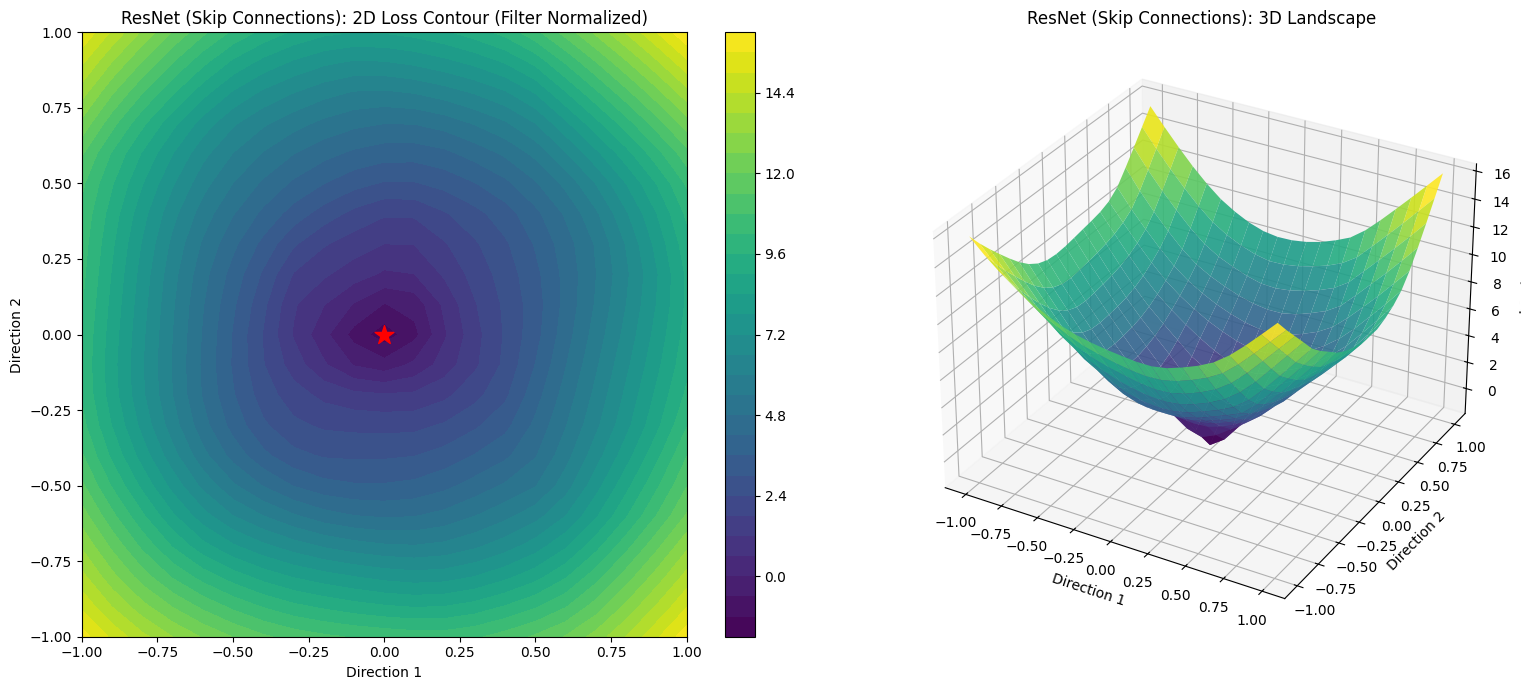

In [ ]:
# 3. Analyze ResNet
print("\nAnalyzing ResNet Geometry...")
lambda_resnet = compute_hessian_spectral_norm(model_resnet, criterion, train_loader, DEVICE)
print(f"ResNet Sharpness (Lambda Max): {lambda_resnet:.4f}")

alphas, betas, surf_resnet = compute_loss_surface(model_resnet, train_loader, criterion, DEVICE)
plot_results(alphas, betas, surf_resnet, "ResNet (Skip Connections)")


In [ ]:
# 4. Experiment B: Standard CNN (Architecture without Skip Connections)
model_cnn = get_model('cnn')
model_cnn, _ = train_model(model_cnn, train_loader, epochs=5, name="Standard CNN")



--- Training Standard CNN ---
Epoch 1/5 | Loss: 1.6290
Epoch 2/5 | Loss: 1.1746
Epoch 3/5 | Loss: 0.9710
Epoch 4/5 | Loss: 0.8421
Epoch 5/5 | Loss: 0.7318



Analyzing Standard CNN Geometry...
CNN Sharpness (Lambda Max): 36.2074
Scanning Landscape (21x21)...


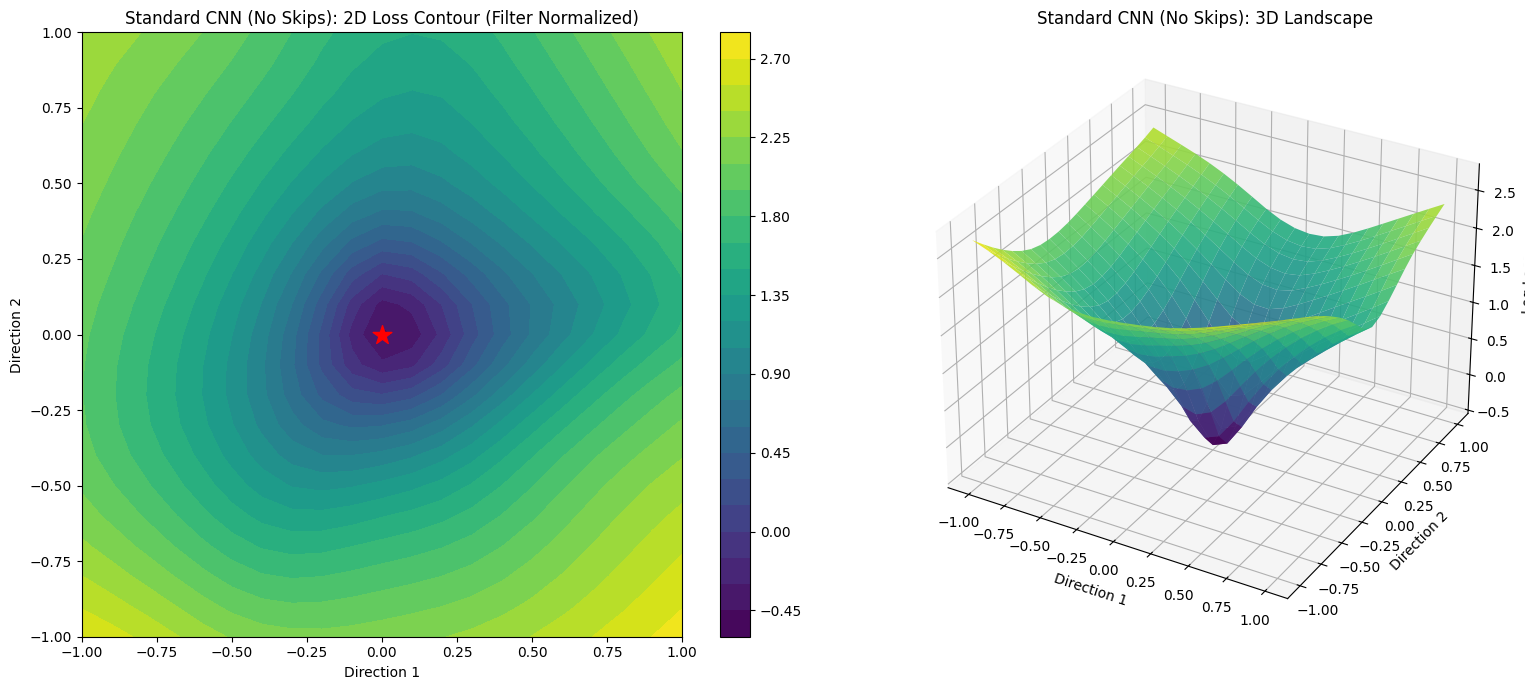

In [ ]:
# 5. Analyze Standard CNN
print("\nAnalyzing Standard CNN Geometry...")
lambda_cnn = compute_hessian_spectral_norm(model_cnn, criterion, train_loader, DEVICE)
print(f"CNN Sharpness (Lambda Max): {lambda_cnn:.4f}")

alphas, betas, surf_cnn = compute_loss_surface(model_cnn, train_loader, criterion, DEVICE)
plot_results(alphas, betas, surf_cnn, "Standard CNN (No Skips)")

# Batch Size : 64

In [ ]:
BATCH_SIZE = 64

In [ ]:
# 1. Data Setup (CIFAR-10)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)


In [ ]:
# 2. Experiment A: ResNet (Architecture with Skip Connections)
model_resnet = get_model('resnet')
model_resnet, criterion = train_model(model_resnet, train_loader, epochs=5, name="ResNet")



--- Training ResNet ---
Epoch 1/5 | Loss: 1.3794
Epoch 2/5 | Loss: 0.8185
Epoch 3/5 | Loss: 0.5671
Epoch 4/5 | Loss: 0.3891
Epoch 5/5 | Loss: 0.2582



Analyzing ResNet Geometry...
ResNet Sharpness (Lambda Max): 281.4219
Scanning Landscape (21x21)...


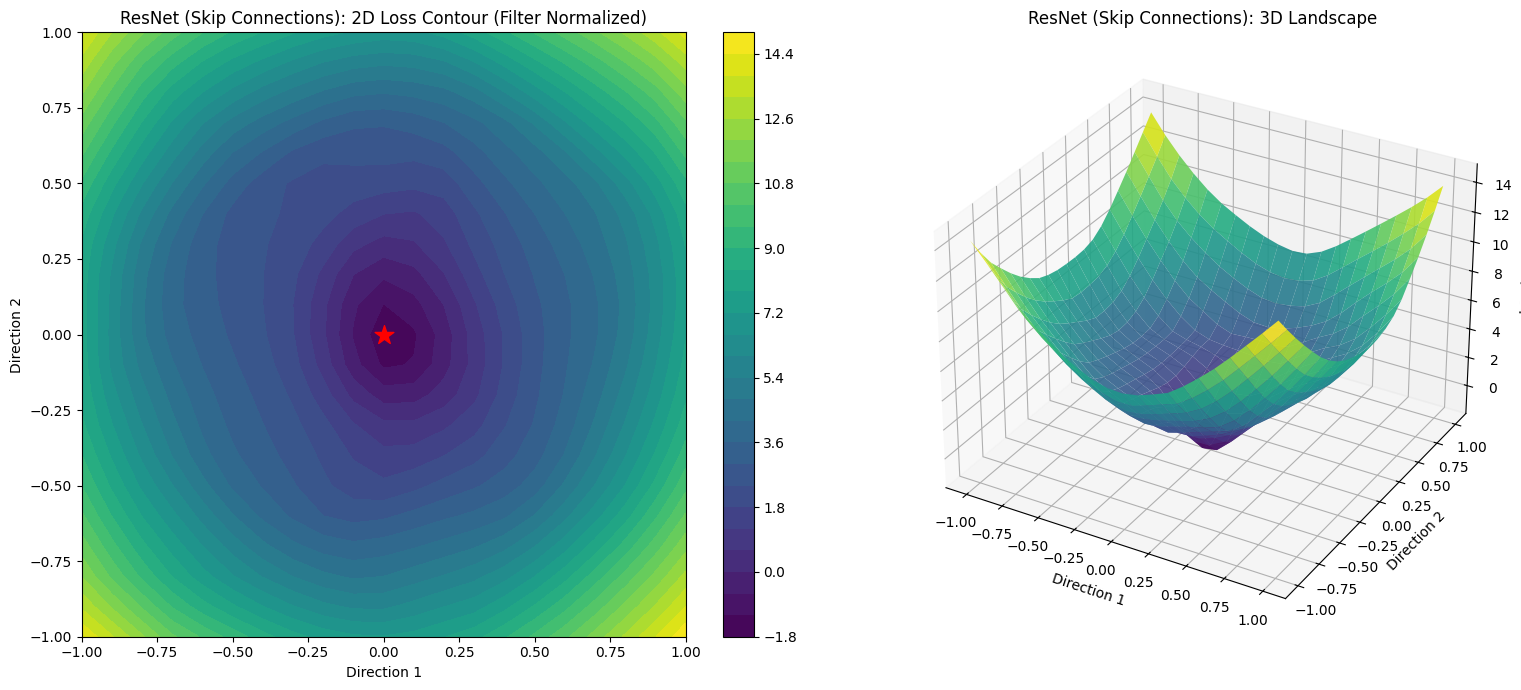

In [ ]:
# 3. Analyze ResNet
print("\nAnalyzing ResNet Geometry...")
lambda_resnet = compute_hessian_spectral_norm(model_resnet, criterion, train_loader, DEVICE)
print(f"ResNet Sharpness (Lambda Max): {lambda_resnet:.4f}")

alphas, betas, surf_resnet = compute_loss_surface(model_resnet, train_loader, criterion, DEVICE)
plot_results(alphas, betas, surf_resnet, "ResNet (Skip Connections)")


In [ ]:
# 4. Experiment B: Standard CNN (Architecture without Skip Connections)
model_cnn = get_model('cnn')
model_cnn, _ = train_model(model_cnn, train_loader, epochs=5, name="Standard CNN")



--- Training Standard CNN ---
Epoch 1/5 | Loss: 1.4660
Epoch 2/5 | Loss: 1.0169
Epoch 3/5 | Loss: 0.8188
Epoch 4/5 | Loss: 0.6693
Epoch 5/5 | Loss: 0.5361



Analyzing Standard CNN Geometry...
CNN Sharpness (Lambda Max): 32.8628
Scanning Landscape (21x21)...


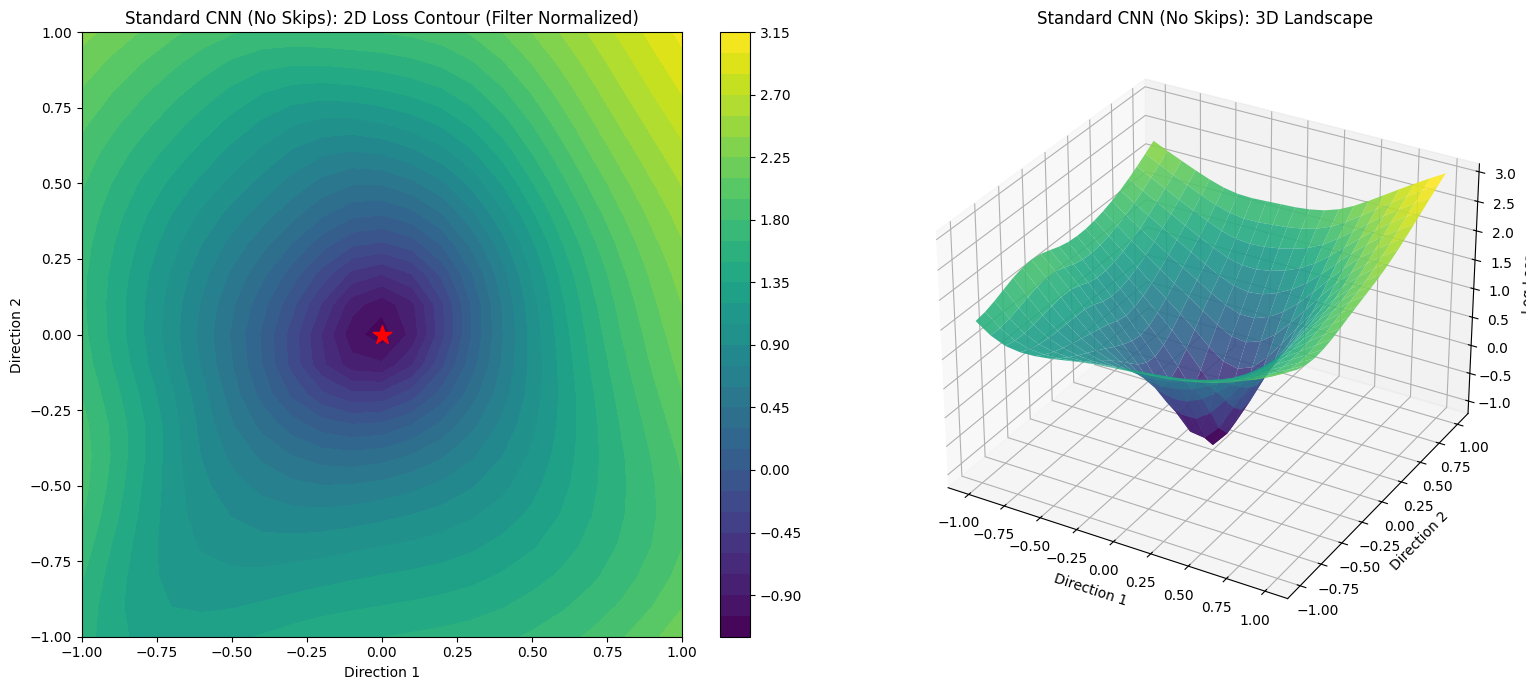

In [ ]:
# 5. Analyze Standard CNN
print("\nAnalyzing Standard CNN Geometry...")
lambda_cnn = compute_hessian_spectral_norm(model_cnn, criterion, train_loader, DEVICE)
print(f"CNN Sharpness (Lambda Max): {lambda_cnn:.4f}")

alphas, betas, surf_cnn = compute_loss_surface(model_cnn, train_loader, criterion, DEVICE)
plot_results(alphas, betas, surf_cnn, "Standard CNN (No Skips)")


# Batch size : 1024

In [7]:
BATCH_SIZE = 1024

In [8]:
# 1. Data Setup (CIFAR-10)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


In [9]:
# 2. Experiment A: ResNet (Architecture with Skip Connections)
model_resnet = get_model('resnet')
model_resnet, criterion = train_model(model_resnet, train_loader, epochs=5, name="ResNet")



--- Training ResNet ---
Epoch 1/5 | Loss: 1.9272
Epoch 2/5 | Loss: 1.4468
Epoch 3/5 | Loss: 1.2300
Epoch 4/5 | Loss: 1.0738
Epoch 5/5 | Loss: 0.9362


In [10]:
# 3. Analyze ResNet
print("\nAnalyzing ResNet Geometry...")
lambda_resnet = compute_hessian_spectral_norm(model_resnet, criterion, train_loader, DEVICE)
print(f"ResNet Sharpness (Lambda Max): {lambda_resnet:.4f}")

alphas, betas, surf_resnet = compute_loss_surface(model_resnet, train_loader, criterion, DEVICE)
plot_results(alphas, betas, surf_resnet, "ResNet (Skip Connections)")



Analyzing ResNet Geometry...


OutOfMemoryError: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 40.12 MiB is free. Process 3827 has 14.70 GiB memory in use. Of the allocated memory 14.34 GiB is allocated by PyTorch, and 225.48 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# 4. Experiment B: Standard CNN (Architecture without Skip Connections)
model_cnn = get_model('cnn')
model_cnn, _ = train_model(model_cnn, train_loader, epochs=5, name="Standard CNN")


In [ ]:
# 5. Analyze Standard CNN
print("\nAnalyzing Standard CNN Geometry...")
lambda_cnn = compute_hessian_spectral_norm(model_cnn, criterion, train_loader, DEVICE)
print(f"CNN Sharpness (Lambda Max): {lambda_cnn:.4f}")

alphas, betas, surf_cnn = compute_loss_surface(model_cnn, train_loader, criterion, DEVICE)
plot_results(alphas, betas, surf_cnn, "Standard CNN (No Skips)")
